Helper functions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd
import torch
from scipy.integrate import solve_ivp
from collections.abc import Callable
from typing import Tuple, Optional
from scipy.integrate import odeint
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.integrate import solve_ivp

# Helper: wrap a PyTorch model that takes a torch tensor of shape (N,) or (N,1)
def make_torch_wrapper(pt_model, device="cpu", batch_dim=False):
    """
    Wrap a PyTorch model so it can be called as a numpy function u -> out (numpy array).
    - pt_model should accept a torch tensor of shape (N,) or (N,1) and return (N,) or (N,1)
    - device: 'cpu' or 'cuda'
    - batch_dim: if True, the model expects input shape (batch, N) or similar; keep False for elementwise
    Returns: callable(u_numpy) -> numpy array
    """
    pt_model.to(device)
    pt_model.eval()
    def wrapper(u_np: np.ndarray) -> np.ndarray:
        # Convert to torch tensor
        with torch.no_grad():
            u_t = torch.from_numpy(u_np.astype(np.float32)).to(device)
            # If model expects shape (N,1), reshape
            if u_t.ndim == 1:
                u_t_in = u_t.unsqueeze(1)  # (N,1)
            else:
                u_t_in = u_t
            out = pt_model(u_t_in)
            # If out has shape (N,1) or (N,), convert to 1D numpy
            out_np = out.detach().cpu().numpy()
            out_np = out_np.reshape(u_np.shape)
        return out_np
    return wrapper

# Generate training data 
"""
u_t = d/dx( nu * u_x - u*V(u) ), with V(u) = u*(1-u)
i.e. u_t = - d/dx( u^2 (1-u) ) + nu * u_xx
"""
def f_of_u(u):
    """Nonlinear flux function"""
    return mu * (u**2) * (1.0 - u)

def convective_vector(u):
    """
    Assemble global vector from: C_i = ∫ (dphi_i/dx) * f(u) dx
    Using 2-point Gauss quadrature on each element
    """
    C = np.zeros_like(u)
    
    # Gauss quadrature points on reference element [-1, 1]
    xi_gauss = np.array([-1.0/np.sqrt(3.0), 1.0/np.sqrt(3.0)])
    
    for e in range(Nx_elements):
        n0 = e
        n1 = e + 1
        u0 = u[n0]
        u1 = u[n1]
        
        # Evaluate u at quadrature points (linear interpolation)
        # u(xi) = 0.5*(1-xi)*u0 + 0.5*(1+xi)*u1
        uq = 0.5 * (1.0 - xi_gauss) * u0 + 0.5 * (1.0 + xi_gauss) * u1
        
        # Evaluate flux at quadrature points
        fq = f_of_u(uq)
        
        # Integrate f(u) over element using Gauss quadrature
        # ∫_{x0}^{x1} f(u) dx ≈ (h/2) * sum(w_q * f(u_q)) where w_q = 1
        integral_f = (h0 / 2.0) * np.sum(fq)
        
        # Basis function derivatives: dphi_0/dx = -1/h, dphi_1/dx = +1/h
        # Local contribution: dphi_i/dx * ∫ f(u) dx
        local = np.array([-1.0, 1.0]) * (integral_f / h0)
        
        C[n0] += local[0]
        C[n1] += local[1]
    
    return C

def rhs_Mu(u):
    """Compute RHS vector: -K_diff @ u + convective_vector(u)"""
    return -K_diff.dot(u) + convective_vector(u)

def odefun(t, u):
    """ODE function: du/dt = M^{-1} * RHS(u)"""
    rhs = rhs_Mu(u)
    du_dt = M_factor(rhs)
    return du_dt

# Initial condition
def initial_condition(x):
    return np.exp(-(x) ** 2 / 2)

# reconstruct the solution using the learned NN 'D_model' and 'V_model' at the training points (x_train, t_train)
def recon_plot(x_train, t_train, D_model, V_model, u_NN_IC):
    D_callable = make_torch_wrapper(D_model, device='cpu')
    V_callable = make_torch_wrapper(V_model, device='cpu')
    u_sim = simulate_pde(x_train, u_NN_IC, D_callable, V_callable,
                       t_span=(t_train[0], t_train[-1]),
                       t_eval=t_train,
                       integrator="RK45")
    return u_sim

def simulate_pde(x: np.ndarray,
                 IC: np.ndarray,
                 D_callable: Callable[[np.ndarray], np.ndarray],
                 V_callable: Callable[[np.ndarray], np.ndarray],
                 t_span: Tuple[float, float] = (0.0, 20.0),
                 t_eval: Optional[np.ndarray] = None,
                 integrator: str = "RK45",
                 rtol: float = 1e-6,
                 atol: float = 1e-8,
                 save_path: Optional[str] = None,
                 upwind: bool = True,
                 D_average: str = "arithmetic",
                 return_full_sol: bool = False):
    """
    Simulate u_t = ( D(u) * u_x - u * V(u) )_x  on a 1D grid with zero-flux (Neumann) boundaries.

    Parameters
    ----------
    x : np.ndarray
        1D grid (monotonic). Can be non-uniform.
    IC : np.ndarray
        Initial condition (same length as x).
    D_callable : Callable[[np.ndarray], np.ndarray]
        Function mapping u_array -> D_array (same length as u).
    V_callable : Callable[[np.ndarray], np.ndarray]
        Function mapping u_array -> V_array (same length as u).
    t_span : tuple(float, float)
        (t0, tf)
    t_eval : np.ndarray or None
        Times to evaluate solution. If None, uses 201 points between t0 and tf.
    integrator : str
        ODE solver name for solve_ivp (e.g. "RK45", "BDF" for stiff problems).
    rtol, atol : float
        Solver tolerances.
    save_path : str or None
        If provided, saves final state (u at last t_eval) to this .npy path.
    upwind : bool
        If True, use first-order upwind for advective flux (stable for advection).
        If False, use central (averaged) flux for advection (less dissipative but can oscillate).
    D_average : {"arithmetic", "harmonic"}
        How to compute D at interfaces from node values. Harmonic can be better for
        strongly varying diffusivity.
    return_full_sol : bool
        If True, return (sol, sol.y.T) where sol.y.T is shape (len(t_eval), N).
        Otherwise return sol only.

    Returns
    -------
    sol : OdeResult
        The object returned by scipy.integrate.solve_ivp.
        (Optionally also the transposed solution array if return_full_sol=True)
    """

    x = np.asarray(x)
    if x.ndim != 1:
        raise ValueError("x must be a 1D array of grid points.")
    N = x.size

    IC = np.asarray(IC)
    if IC.shape != x.shape:
        raise ValueError("IC must have same shape as x.")

    # mesh spacing (supports non-uniform)
    dxs = np.diff(x)  # length N-1
    if np.any(dxs <= 0):
        raise ValueError("x must be strictly increasing.")

    if t_eval is None:
        t_eval = np.linspace(t_span[0], t_span[1], 201)

    def interface_average(Dn: np.ndarray) -> np.ndarray:
        # Dn length N -> returns D_half length N-1 on interfaces i+1/2
        if D_average == "arithmetic":
            return 0.5 * (Dn[:-1] + Dn[1:])
        elif D_average == "harmonic":
            # avoid divide-by-zero: add a tiny epsilon if necessary
            eps = 1e-12
            return 2.0 * (Dn[:-1] * Dn[1:]) / (Dn[:-1] + Dn[1:] + eps)
        else:
            raise ValueError("D_average must be 'arithmetic' or 'harmonic'")

    def rhs(t, u_vec):
        u = np.asarray(u_vec)
        if u.shape[0] != N:
            raise ValueError("u_vec must have length N")

        # Evaluate D and V at physical nodes
        Dn = D_callable(u)
        Vn = V_callable(u)
        if Dn.shape != u.shape:
            raise ValueError("D_callable must return array of same shape as u")
        if Vn.shape != u.shape:
            raise ValueError("V_callable must return array of same shape as u")

        # ------------------------------------------------------------
        # Ghost-node extension imposing Neumann BC: u_x = 0
        # Using mirrored ghost nodes:
        #   u_{-1} = u_1,   u_N = u_{N-2}
        # so that centered boundary derivative is zero.
        # ------------------------------------------------------------
        u_ext = np.empty(N + 2, dtype=u.dtype)
        u_ext[1:-1] = u
        u_ext[0] = u[1]
        u_ext[-1] = u[-2]

        # Extend D and V consistently to ghost nodes
        D_ext = np.empty(N + 2, dtype=Dn.dtype)
        V_ext = np.empty(N + 2, dtype=Vn.dtype)
        D_ext[1:-1] = Dn
        V_ext[1:-1] = Vn
        D_ext[0] = Dn[1]
        D_ext[-1] = Dn[-2]
        V_ext[0] = Vn[1]
        V_ext[-1] = Vn[-2]

        # Extended interface spacings, length N+1
        # interfaces are:
        #   x_{-1/2}, x_{1/2}, ..., x_{N-3/2}, x_{N-1/2}
        dx_ext = np.empty(N + 1, dtype=float)
        dx_ext[1:-1] = dxs
        dx_ext[0] = dxs[0]
        dx_ext[-1] = dxs[-1]

        # Interface values for D and V, length N+1
        D_half = 0.5 * (D_ext[:-1] + D_ext[1:])
        V_half = 0.5 * (V_ext[:-1] + V_ext[1:])

        # Diffusive flux at all interfaces
        diff_flux = D_half * (u_ext[1:] - u_ext[:-1]) / dx_ext

        # Advective flux at all interfaces
        if upwind:
            u_left = u_ext[:-1]
            u_right = u_ext[1:]
            u_hat = np.where(V_half >= 0, u_left, u_right)
            adv_flux = V_half * u_hat
        else:
            u_avg = 0.5 * (u_ext[:-1] + u_ext[1:])
            adv_flux = V_half * u_avg

        # Total flux at all interfaces:
        # F = D(u) u_x - u V(u)
        flux = diff_flux - adv_flux   # length N+1

        # Conservative divergence at physical nodes
        dx_node = np.empty(N, dtype=float)
        if N == 1:
            dx_node[0] = 1.0
        else:
            dx_node[0] = dxs[0]
            dx_node[-1] = dxs[-1]
            if N > 2:
                dx_node[1:-1] = 0.5 * (dxs[:-1] + dxs[1:])

        dudt = (flux[1:] - flux[:-1]) / dx_node
        return dudt

    sol = solve_ivp(rhs, t_span, IC, method=integrator, t_eval=t_eval, rtol=rtol, atol=atol)

    return sol.y.T


Plot formatting and setups

In [2]:
# plot formatting
plt.rcParams['font.family'] = 'overall_overall_times New Roman'
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelweight'] = 'bold'  # Bold axis labels
plt.rcParams['axes.titleweight'] = 'bold'  # Bold title
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = str(20)
plt.rcParams['lines.linewidth'] = 2
alpha_val = 0.4

# epochs for training history
epoch_hist = np.arange(0, 4001, 1)

# training data
mu = 0.6 # coefficient for the advection term
nu = 0.01 # diffusion coefficient

# time resolution
Nt, t_end, t_min = 7, 18.0, 0.0
t_train = np.linspace(t_min, t_end, Nt)

# spatial resolutions
L = 7.0
x_min, x_max = -L, L
dx = 0.04
x_train = np.arange(x_min, x_max+dx, dx)
Nx = len(x_train)
Nx_elements = Nx - 1 # 350 elements
# prepare the FEM matrices for the PDE solver
h = np.diff(x_train)
assert np.allclose(h, h[0]), "Code assumes uniform spacing"
h0 = h[0]
# Assembly: mass matrix M and diffusion stiffness K
rows = []
cols = []
data_M = []
data_K = []
for e in range(Nx_elements):
    n0 = e
    n1 = e + 1
    # local mass matrix for P1 elements
    Me = (h0 / 6.0) * np.array([[2.0, 1.0], [1.0, 2.0]])
    # local stiffness matrix
    Ke = (1.0 / h0) * np.array([[1.0, -1.0], [-1.0, 1.0]])
    for i_local, i_glob in enumerate([n0, n1]):
        for j_local, j_glob in enumerate([n0, n1]):
            rows.append(i_glob)
            cols.append(j_glob)
            data_M.append(Me[i_local, j_local])
            data_K.append(Ke[i_local, j_local])
M = sp.coo_matrix((data_M, (rows, cols)), shape=(Nx, Nx)).tocsr()
K_base = sp.coo_matrix((data_K, (rows, cols)), shape=(Nx, Nx)).tocsr()
K_diff = nu * K_base
# Pre-factorize mass matrix
M_csc = M.tocsc()
M_factor = spla.factorized(M_csc)

# Initial condition
u0 = initial_condition(x_train)
# Solve with stiff solver
sol = solve_ivp(odefun, (t_min, t_end), u0, method='Radau', t_eval=t_train, atol=1e-8, rtol=1e-6)
u_true = sol.y
u_true = u_true.T # shape (Nt, Nx)

X, T = np.meshgrid(x_train, t_train)

u_min_np, u_max_np = u_true.min(), u_true.max()
U_grid= np.linspace(u_min_np, u_max_np, Nx)

D_true = nu * np.ones(np.shape(U_grid)) # the true diffusion coefficient
V_true = mu * U_grid * (1 - U_grid) # the true advection function

# the variances we used 
variances = [0.0, 0.01, 0.001]
seed = 2

NumRep = 10

top_load_folder = '../ARCresults/Complex_Advection/'
top_save_folder = '../Figures/Fig6/'

subfolders = ['DandV_NN_structure_var0.0/', 'DandV_NN_structure_var0.01/', 'DandV_NN_structure_var0.001/']

DV_structures = np.array([[1, 1, 1, 1], # 
                        [1, 1, 4, 1],
                        [1, 1, 4, 4],
                        [1, 1, 4, 32], 

                        [4, 1, 1, 1], 
                        [4, 1, 4, 1], # 
                        [4, 1, 4, 4],
                        [4, 1, 4, 32],

                        [4, 4, 1, 1], 
                        [4, 4, 4, 4], # 
                        [4, 4, 4, 32],
                        [4, 4, 4, 1],
                                
                        [4, 32, 1, 1], 
                        [4, 32, 4, 1],
                        [4, 32, 4, 4],
                        [4, 32, 4, 32]] #
                        )
DV_structures1 = np.array([
                          [1, 1, 1, 1],
                          [4, 1, 4, 1],
                          [4, 4, 4, 4],
                          [4, 32, 4, 32] # 
                          ])
indices_1 = [0, 5, 9, 15]

colors1 = sns.color_palette("Set2", len(DV_structures1))
alpha_val = 0.4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Plot: total validation loss

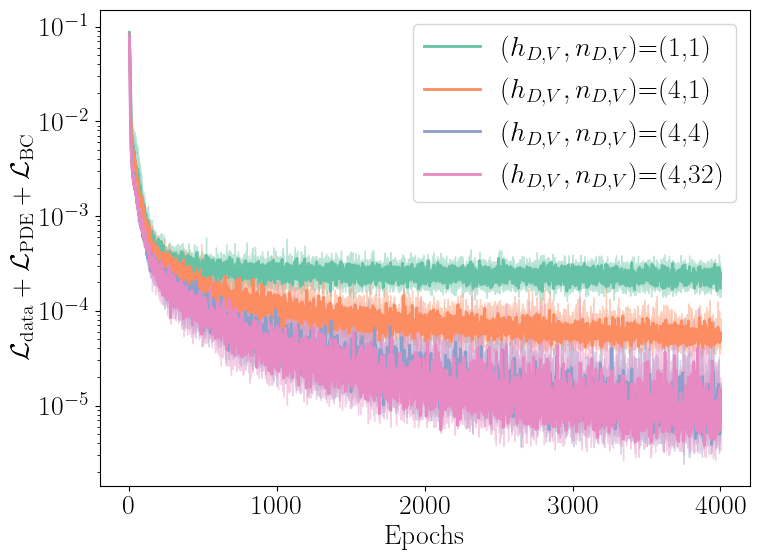

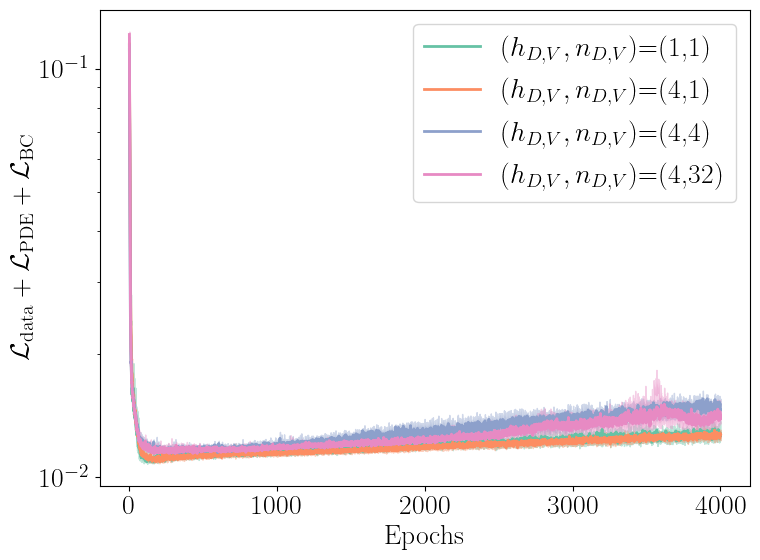

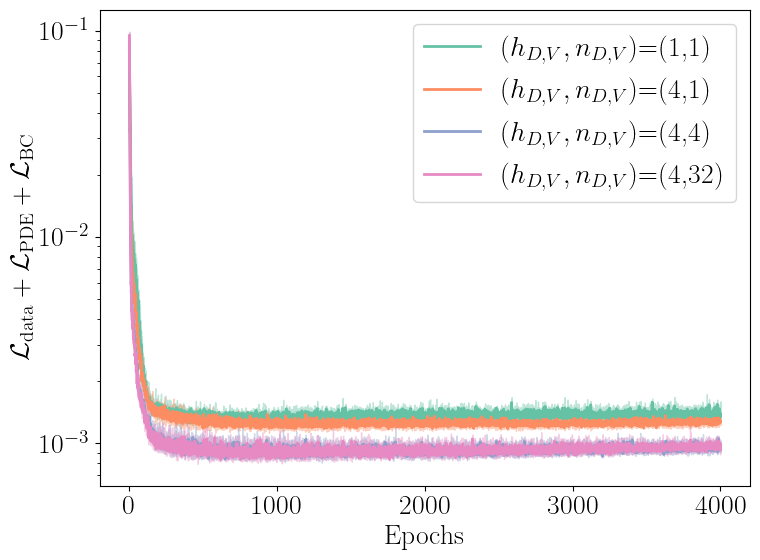

In [3]:
for var, subfolder in zip(variances, subfolders):

    load_dir = top_load_folder + subfolder
    save_dir = top_save_folder + f'var{var}/'

    fig1, ax1 = plt.subplots(figsize=(8, 6))

    for struct_ind in range(len(DV_structures1)):
        D_num_layers, D_hidden_units, V_num_layers, V_hidden_units = DV_structures1[struct_ind]
        D_num_layers, D_hidden_units = int(D_num_layers), int(D_hidden_units)
        V_num_layers, V_hidden_units = int(V_num_layers), int(V_hidden_units)
        val_pdeloss_S = np.load(load_dir + f'Dhlayer{D_num_layers}_Dnode{D_hidden_units}_Vhlayer{V_num_layers}_Vnode{V_hidden_units}/val_pdeloss_S.npy', allow_pickle=True)
        val_uloss_S = np.load(load_dir + f'Dhlayer{D_num_layers}_Dnode{D_hidden_units}_Vhlayer{V_num_layers}_Vnode{V_hidden_units}/val_uloss_S.npy', allow_pickle=True)
        val_BCloss_S = np.load(load_dir + f'Dhlayer{D_num_layers}_Dnode{D_hidden_units}_Vhlayer{V_num_layers}_Vnode{V_hidden_units}/val_BCloss_S.npy', allow_pickle=True)
        val_pdeloss_S, val_uloss_S, val_BCloss_S = np.asarray(val_pdeloss_S, dtype=float), np.asarray(val_uloss_S, dtype=float), np.asarray(val_BCloss_S, dtype=float)
        total_loss = val_uloss_S + val_BCloss_S + val_pdeloss_S
        median_total_loss = np.median(total_loss, axis=0)
        q1_total_loss = np.percentile(total_loss, 25, axis=0)
        q3_total_loss = np.percentile(total_loss, 75, axis=0)
        ax1.plot(epoch_hist, median_total_loss, label=rf'$(h_{{D, V}},n_{{D, V}})$=({D_num_layers},{D_hidden_units})', color=colors1[struct_ind])
        ax1.fill_between(epoch_hist, q1_total_loss, q3_total_loss, color=colors1[struct_ind], alpha=alpha_val)
    ax1.set_yscale('log')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel(r'$\mathcal{L}_{\mathrm{data}} + \mathcal{L}_{\mathrm{PDE}} + \mathcal{L}_{\mathrm{BC}}$')
    ax1.legend(loc='upper right')
    fig1.tight_layout()
    fig1.savefig(save_dir + f'total_valLoss_var{var}.svg', format='svg', bbox_inches='tight')
    

Loop through NN structures for D_NN and V_NN to store u_reconstr, L2RE for u_reconstr

In [4]:
for var, subfolder in zip(variances, subfolders):
    noise_level = np.sqrt(var)
    np.random.seed(seed)
    additive_noise = noise_level * np.random.randn(*u_true.shape)
    u_true_noisy_IC = u_true + additive_noise

    print(f"Processing variance {var}...")

    load_dir = top_load_folder + subfolder
    save_dir = top_save_folder + f'var{var}/'

    u_reconstr_S = []
    l2_errors = []

    for struct_ind in range(0, len(DV_structures)):
        D_num_layers, D_hidden_units, V_num_layers, V_hidden_units = DV_structures[struct_ind]
        D_num_layers, D_hidden_units = int(D_num_layers), int(D_hidden_units)
        V_num_layers, V_hidden_units = int(V_num_layers), int(V_hidden_units)
        print("Structure: D layers {}, D nodes {}, V layers {}, V nodes {}".format(D_num_layers, D_hidden_units, V_num_layers, V_hidden_units))

        u_reconstr = []
        l2re = []

        u_netS = np.load(load_dir + f'Dhlayer{D_num_layers}_Dnode{D_hidden_units}_Vhlayer{V_num_layers}_Vnode{V_hidden_units}/u_predS.npy')
        
        for rep in range(NumRep):
            # load the trained models
            D_model = torch.load(load_dir + f'Dhlayer{D_num_layers}_Dnode{D_hidden_units}_Vhlayer{V_num_layers}_Vnode{V_hidden_units}/Iter{rep}/D_net_best_Iter{rep}.pth', map_location=torch.device('cpu'), weights_only=False)
            V_model = torch.load(load_dir + f'Dhlayer{D_num_layers}_Dnode{D_hidden_units}_Vhlayer{V_num_layers}_Vnode{V_hidden_units}/Iter{rep}/V_net_best_Iter{rep}.pth', map_location=torch.device('cpu'), weights_only=False)
            
            # ------------------ YY -----------------
            # use the learnt u_NN at t=0 as the initial condition to reconstruct the solution
            u_NN_IC = u_netS[rep, 0, :]
            u_sim = recon_plot(x_train, t_train, D_model, V_model, u_NN_IC)
            if np.shape(u_sim) == (Nt, Nx):
                u_reconstr.append(u_sim)
                l2_error = np.linalg.norm(u_sim - u_true, 2) / np.linalg.norm(u_true, 2)
                l2re.append(l2_error)
            else:
                print(f"Warning: This is for D layers {D_num_layers}, D nodes {D_hidden_units}, V layers {V_num_layers}, V nodes {V_hidden_units}, rep {rep}. Simulation did not return expected shape. Skipping.")
                continue
            
        u_reconstr_S.append(u_reconstr)
        l2_errors.append(l2re)
    #l2_errors = np.array(l2_errors)

    # pickle save 'u_reconstr_var' and 'l2_errors'
    with open(save_dir + f'u_reconstr_var{var}.pkl', 'wb') as f:
        import pickle
        pickle.dump(u_reconstr_S, f)
    with open(save_dir + f'l2RE_u_reconstr_var{var}.pkl', 'wb') as f:
        import pickle
        pickle.dump(l2_errors, f)

Processing variance 0.0...
Structure: D layers 1, D nodes 1, V layers 1, V nodes 1
Structure: D layers 1, D nodes 1, V layers 4, V nodes 1
Structure: D layers 1, D nodes 1, V layers 4, V nodes 4
Structure: D layers 1, D nodes 1, V layers 4, V nodes 32
Structure: D layers 4, D nodes 1, V layers 1, V nodes 1
Structure: D layers 4, D nodes 1, V layers 4, V nodes 1
Structure: D layers 4, D nodes 1, V layers 4, V nodes 4
Structure: D layers 4, D nodes 1, V layers 4, V nodes 32
Structure: D layers 4, D nodes 4, V layers 1, V nodes 1
Structure: D layers 4, D nodes 4, V layers 4, V nodes 4
Structure: D layers 4, D nodes 4, V layers 4, V nodes 32
Structure: D layers 4, D nodes 4, V layers 4, V nodes 1
Structure: D layers 4, D nodes 32, V layers 1, V nodes 1
Structure: D layers 4, D nodes 32, V layers 4, V nodes 1
Structure: D layers 4, D nodes 32, V layers 4, V nodes 4
Structure: D layers 4, D nodes 32, V layers 4, V nodes 32
Processing variance 0.01...
Structure: D layers 1, D nodes 1, V layer

### Plot: heatmap for L2RE of u_reconstr

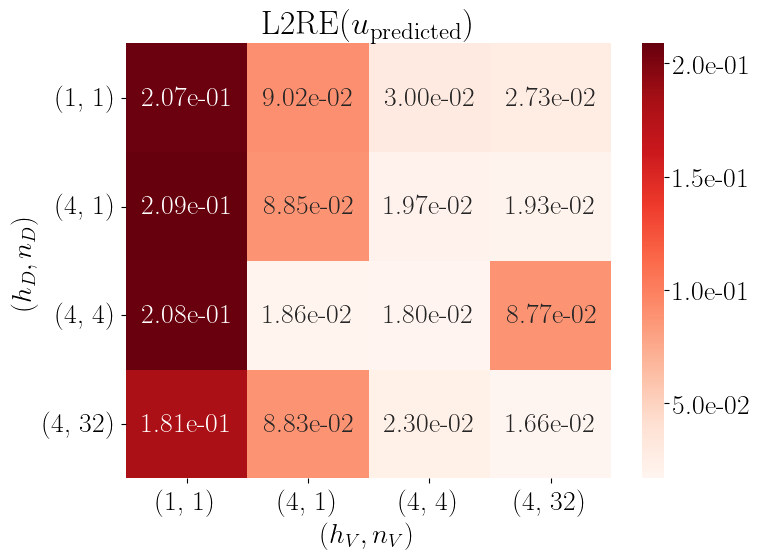

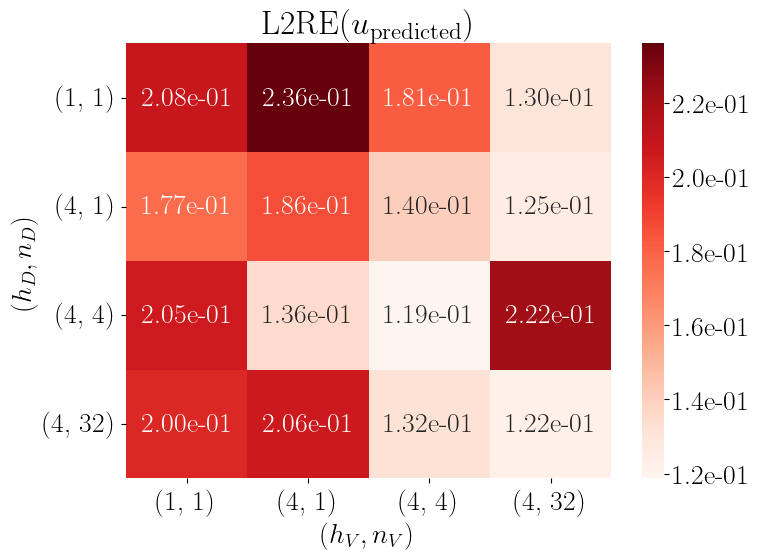

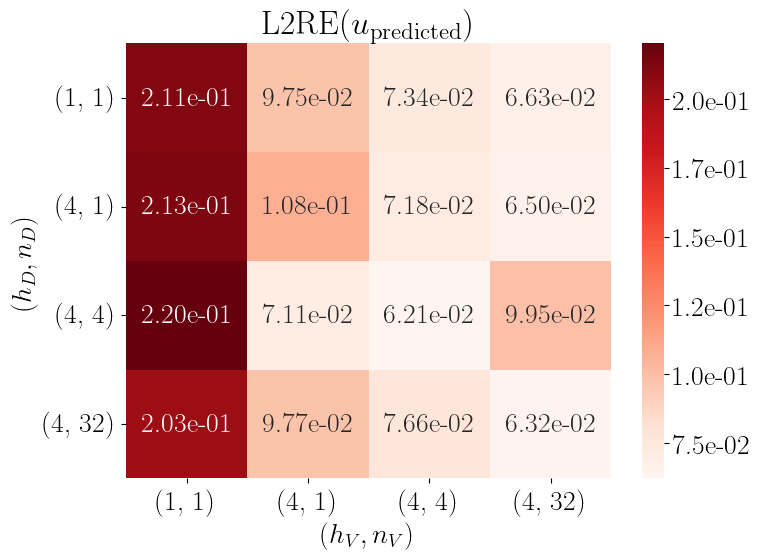

In [5]:
for var, subfolder in zip(variances, subfolders):

    save_dir = top_save_folder + f'var{var}/'

    # pickle load the l2_errors
    with open(save_dir + f'l2RE_u_reconstr_var{var}.pkl', 'rb') as f:
        import pickle
        l2_errors = pickle.load(f)
    median_l2_errors = []
    for i in range(len(l2_errors)):
        median_l2_errors.append(np.median(l2_errors[i]))
    median_l2_errors = np.array(median_l2_errors)
    median_l2_errors_reshaped = median_l2_errors.reshape((4, 4))
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    sns.heatmap(median_l2_errors_reshaped, annot=True, fmt=".2e", cmap="Reds", ax=ax)
    ax.set_xticklabels([(1, 1), (4, 1), (4, 4), (4, 32)], rotation=0)
    ax.set_yticklabels([(1, 1), (4, 1), (4, 4), (4, 32)], rotation=0)
    ax.set_xlabel(r'$(h_{V}, n_{V})$')
    ax.set_ylabel(r'$(h_{D}, n_{D})$')
    ax.set_title(r'L2RE($u_{\mathrm{predicted}}$)')
    # make color bars in scientific notation
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.1e}'))
    fig.tight_layout()
    fig.savefig(save_dir + f'L2RE_u_reconstr_heatmap_var{var}.svg', format='svg', bbox_inches='tight')


    

### Plot: u_NN and u_reconstr

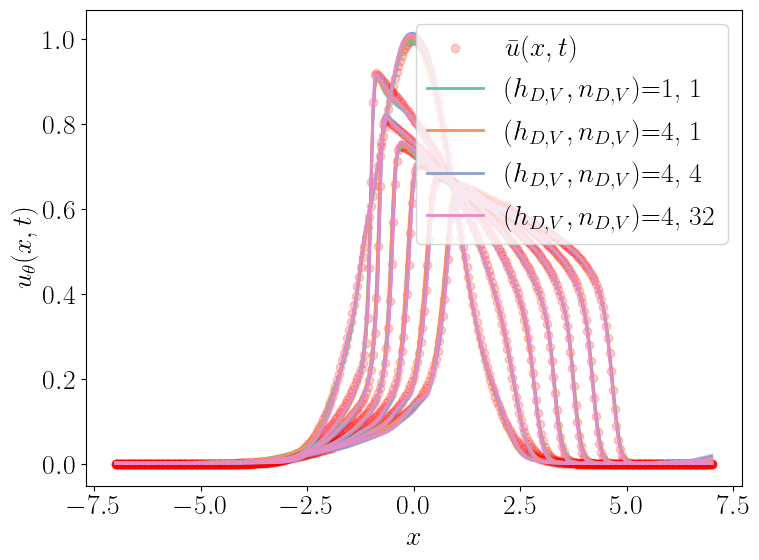

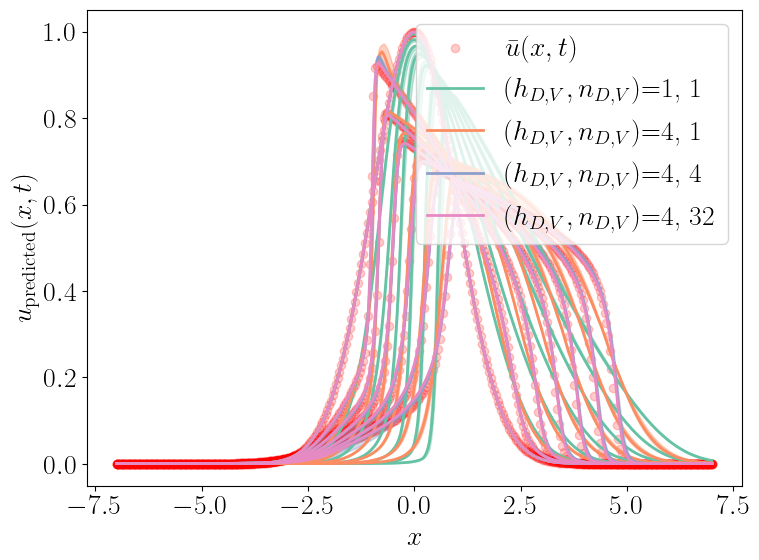

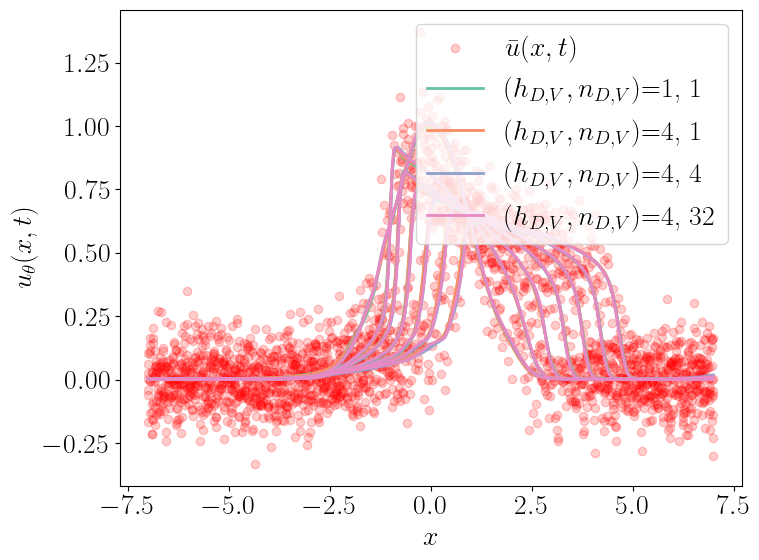

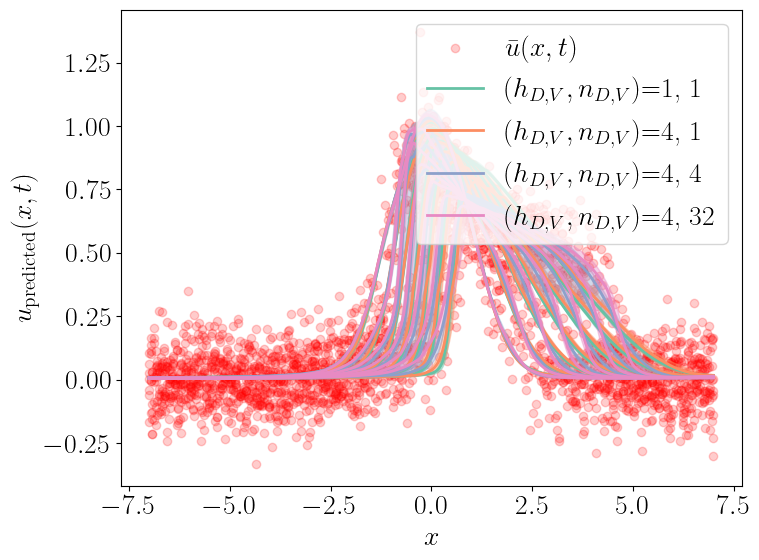

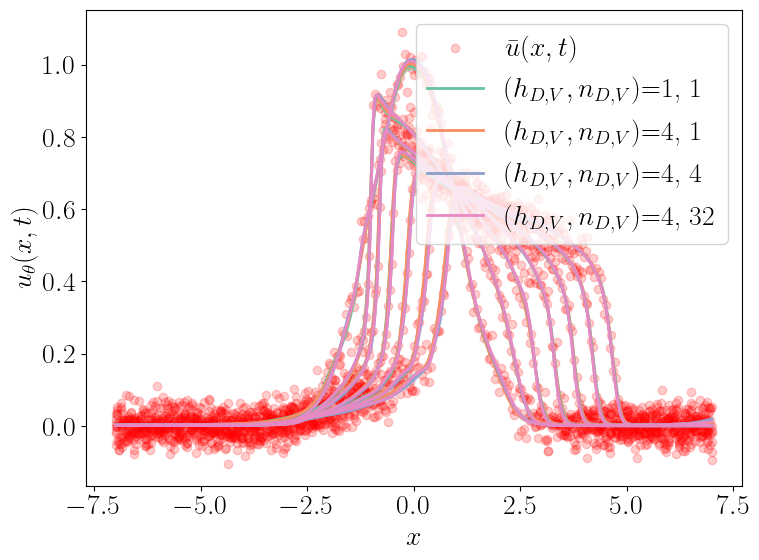

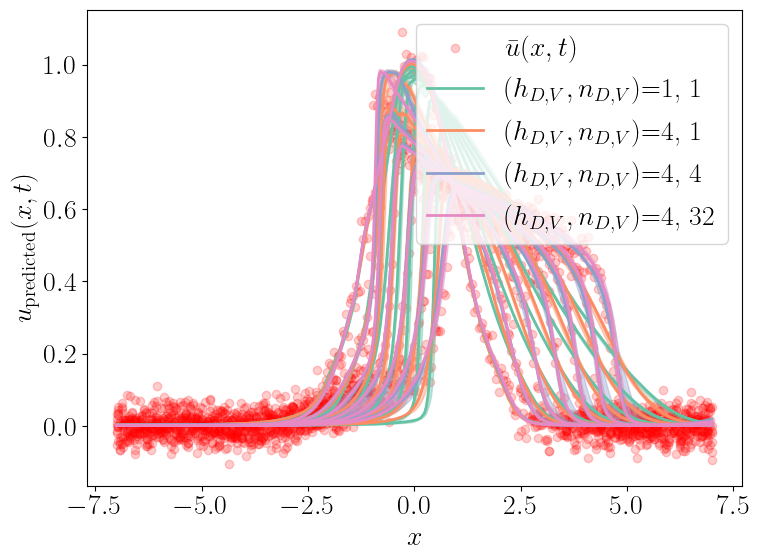

In [9]:
for var, subfolder in zip(variances, DV_structures1):

    save_dir = top_save_folder + f'var{var}/'
    noise_level = np.sqrt(var)
    np.random.seed(seed)
    additive_noise = noise_level * np.random.randn(*u_true.shape)
    u_true_noisy = u_true + additive_noise

    # pickle load the l2_errors
    with open(save_dir + f'u_reconstr_var{var}.pkl', 'rb') as f:
        import pickle
        u_reconstr_var = pickle.load(f)

    fig1, ax1 = plt.subplots(figsize=(8, 6))
    fig2, ax2 = plt.subplots(figsize=(8, 6))
    # plot u_reconstr_medianS with fill_between u_reconstr_q1S and u_reconstr_q3S
    for t in range(len(t_train)):
        ax1.scatter(x_train, u_true_noisy[t, :], color='red', alpha=0.2, label=r'$\bar{u}(x, t)$' if t == 0 else None)
        ax2.scatter(x_train, u_true_noisy[t, :], color='red', alpha=0.2, label=r'$\bar{u}(x, t)$' if t == 0 else None)

    for struct_ind in range(len(DV_structures1)):

        u_reconstr_= u_reconstr_var[indices_1[struct_ind]]
        u_reconstr_medianS, u_reconstr_q1S, u_reconstr_q3S = [], [], []
        for t in range(len(t_train)):
            u_t = []
            for rep in range(len(u_reconstr_)):
                u_t.append(u_reconstr_[rep][t])
            u_t = np.array(u_t)
            u_reconstr_medianS.append(np.median(u_t, axis=0))
            u_reconstr_q1S.append(np.percentile(u_t, 25, axis=0))
            u_reconstr_q3S.append(np.percentile(u_t, 75, axis=0))
        


        D_num_layers, D_hidden_units, V_num_layers, V_hidden_units = DV_structures1[struct_ind]
        D_num_layers, D_hidden_units = int(D_num_layers), int(D_hidden_units)
        V_num_layers, V_hidden_units = int(V_num_layers), int(V_hidden_units)

        # u_NN
        u_NN_all = []
        for rep in range(NumRep):
            test_u_NN_np = np.load(load_dir + f'Dhlayer{D_num_layers}_Dnode{D_hidden_units}_Vhlayer{V_num_layers}_Vnode{V_hidden_units}/Iter{rep}/fullgrid_u_pred.npy')
            u_NN_all.append(test_u_NN_np)
                
        u_NN_median, u_NN_25, u_NN_75 = np.median(np.array(u_NN_all), axis=0), np.percentile(np.array(u_NN_all), 25, axis=0), np.percentile(np.array(u_NN_all), 75, axis=0)

        
        for t in range(len(u_NN_median)):
            ax1.plot(x_train, u_NN_median[t], label=rf'$(h_{{D,V}}, n_{{D,V}})$={V_num_layers}, {V_hidden_units}' if t==0 else "", color=colors1[struct_ind])
            ax1.fill_between(x_train, u_NN_25[t], u_NN_75[t], alpha=alpha_val, color=colors1[struct_ind])
        for t in range(len(u_reconstr_medianS)):
            ax2.plot(x_train, u_reconstr_medianS[t], label=rf'$(h_{{D,V}}, n_{{D,V}})$={V_num_layers}, {V_hidden_units}' if t==0 else "", color=colors1[struct_ind])
            ax2.fill_between(x_train, u_reconstr_q1S[t], u_reconstr_q3S[t], alpha=alpha_val, color=colors1[struct_ind])

    ax1.set_xlabel(r'$x$')
    ax1.set_ylabel(r'$u_{\theta}(x,t)$')
    ax1.legend(loc='upper right')
    fig1.tight_layout()

    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$u_{\mathrm{predicted}}(x,t)$')
    ax2.legend(loc='upper right')
    fig2.tight_layout()
    
    fig1.savefig(save_dir + f'u_NN_var{var}.svg', format='svg', bbox_inches='tight')
    fig2.savefig(save_dir + f'u_reconstr_var{var}.svg', format='svg', bbox_inches='tight')


### Plot: D_NN V_NN for 'DV_structures1'

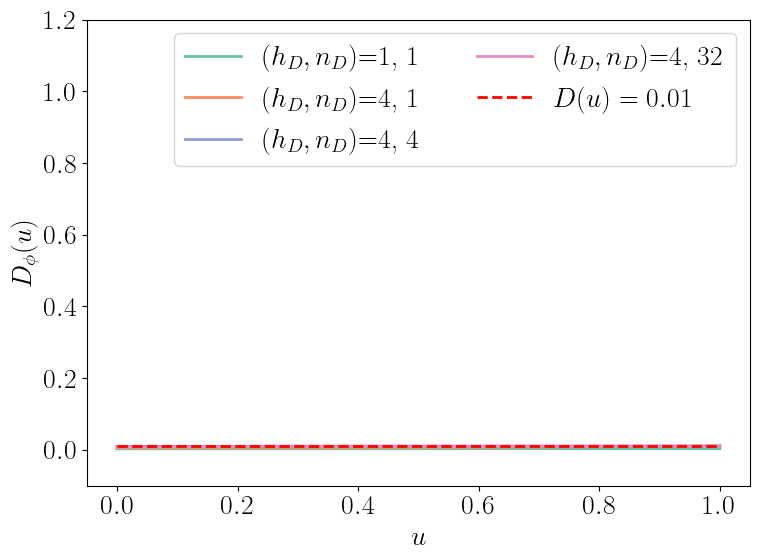

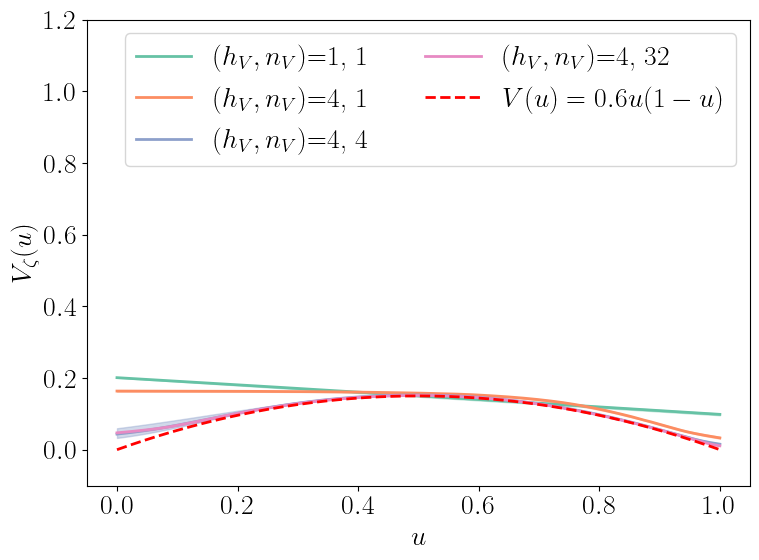

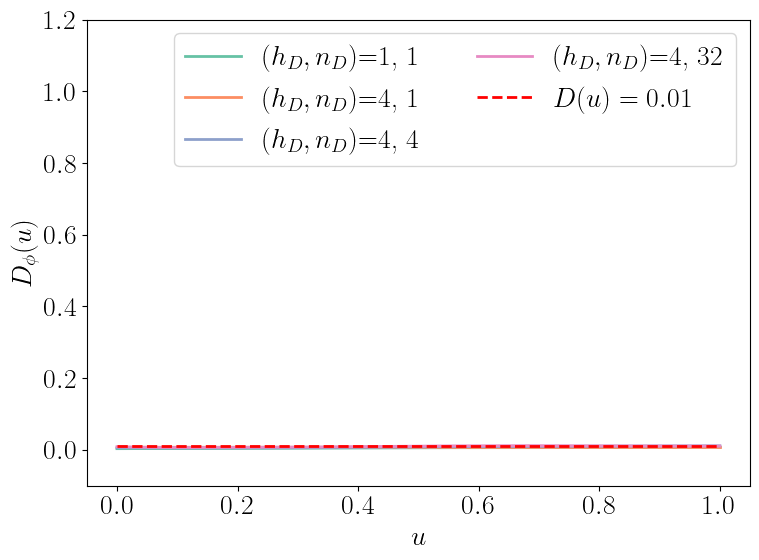

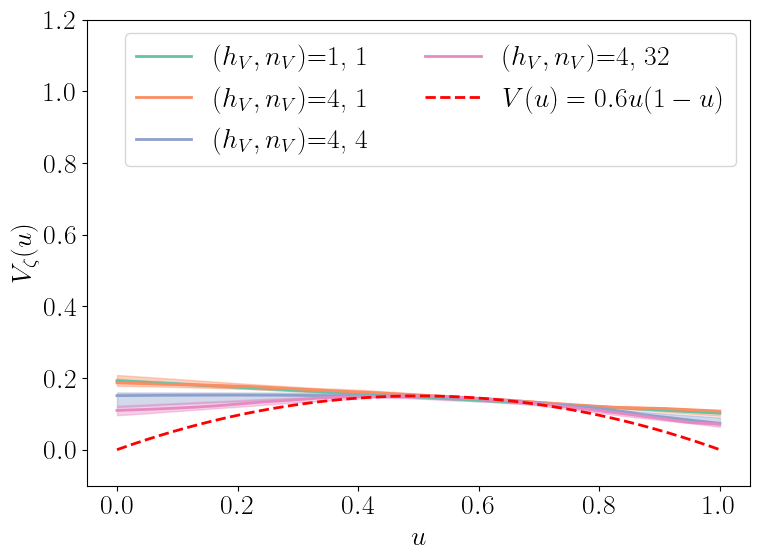

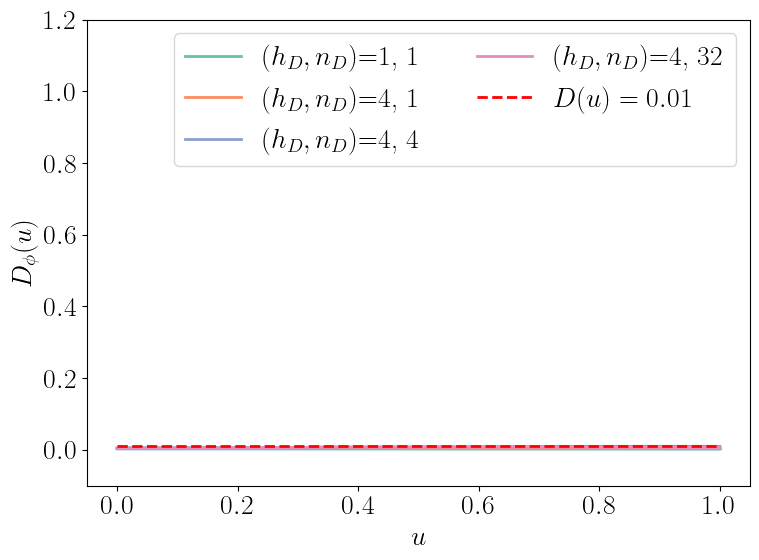

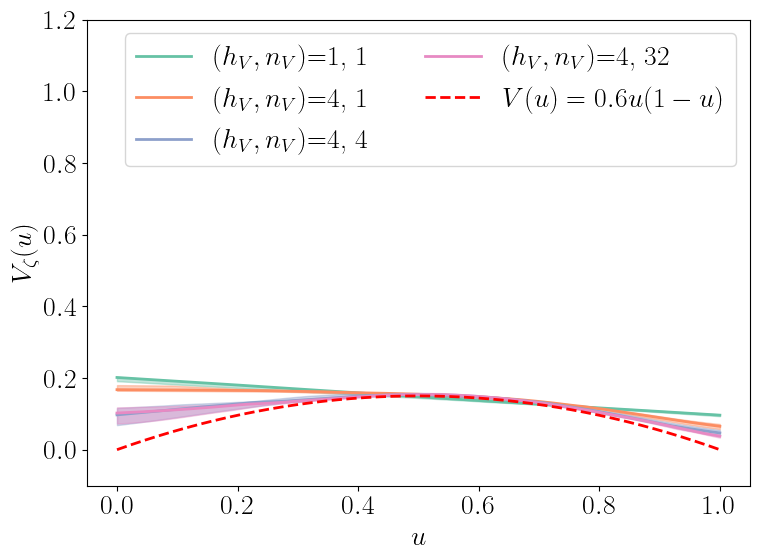

In [10]:
for var, subfolder in zip(variances, subfolders):

    load_dir = top_load_folder + subfolder
    save_dir = top_save_folder + f'var{var}/'


    fig1, ax1 = plt.subplots(1, 1, figsize=(8, 6))
    fig2, ax2 = plt.subplots(1, 1, figsize=(8, 6))

    for struct_ind in range(0, len(DV_structures1)):
        D_num_layers, D_hidden_units, V_num_layers, V_hidden_units = DV_structures1[struct_ind]
        D_num_layers, D_hidden_units = int(D_num_layers), int(D_hidden_units)
        V_num_layers, V_hidden_units = int(V_num_layers), int(V_hidden_units)
        D_reps = np.load(load_dir + f'Dhlayer{D_num_layers}_Dnode{D_hidden_units}_Vhlayer{V_num_layers}_Vnode{V_hidden_units}/D_predS.npy')
        V_reps = np.load(load_dir + f'Dhlayer{D_num_layers}_Dnode{D_hidden_units}_Vhlayer{V_num_layers}_Vnode{V_hidden_units}/V_predS.npy')
        D_median = np.median(D_reps, axis=0)
        D_q1 = np.percentile(D_reps, 25, axis=0)
        D_q3 = np.percentile(D_reps, 75, axis=0)
        V_median = np.median(V_reps, axis=0)
        V_q1 = np.percentile(V_reps, 25, axis=0)
        V_q3 = np.percentile(V_reps, 75, axis=0)

        # Plot D_NN:
        ax1.plot(U_grid, D_median, label=rf'$(h_D, n_D)$={D_num_layers}, {D_hidden_units}', color=colors1[struct_ind])
        ax1.fill_between(U_grid, D_q1, D_q3, color=colors1[struct_ind], alpha=alpha_val)

        # Plot V_NN:
        ax2.plot(U_grid, V_median, label=rf'$(h_V, n_V)$={V_num_layers}, {V_hidden_units}', color=colors1[struct_ind])
        ax2.fill_between(U_grid, V_q1, V_q3, color=colors1[struct_ind], alpha=alpha_val)

    ax1.plot(U_grid, D_true, label='$D(u)=0.01$', color='red', linestyle='--')
    ax2.plot(U_grid, V_true, label='$V(u)=0.6u(1-u)$', color='red', linestyle='--')

    ax1.set_xlabel(r'$u$')
    ax1.set_ylabel(r'$D_{{\phi}}(u)$')
    ax1.legend(loc='upper right', ncol=2)
    ax1.set_ylim([-0.1, 1.2]) 


    ax2.set_xlabel(r'$u$')
    ax2.set_ylabel(r'$V_{{\zeta}}(u)$')
    ax2.legend(loc='upper right', ncol=2)
    ax2.set_ylim([-0.1, 1.2]) 

    fig1.tight_layout()
    fig2.tight_layout()
    fig1.savefig(save_dir + f'D_uNN_var{var}.svg', format='svg', bbox_inches='tight')
    fig2.savefig(save_dir + f'V_uNN_var{var}.svg', format='svg', bbox_inches='tight')
